In [5]:
import numpy as np
import matplotlib.pyplot as plt
from tanalysis import improcess, stitching
from skimage import exposure
import tifffile as tiff


dirname = r"C:\Users\pcanaleta\Documents\Cellpose_segmentation\EXP.HD6.Chips\EXP.HD6.1.1.MatekChips_CXCL10\24h\Originals\24h_CXCL10_Conc10_z5_t8h.lif"

In [2]:
imgs, dim, names, info = improcess.imread(dirname, channel=0, tiles=True)
print(imgs[0].shape)

Reading submitted files: 100%|████████████████████████████████████████| 1/1 [00:31<00:00, 31.09s/it]

All files read!
(97, 6, 14, 1024, 1024)


In [3]:
positions = info['mosaic_position']
res_img_list = stitching.image_reconstruction(imgs, positions)

Calculating translation vectors: 100%|██████████| 11/11 [06:43<00:00, 36.65s/it]


All vectors calculated!


(97, 14, 1985, 2855)


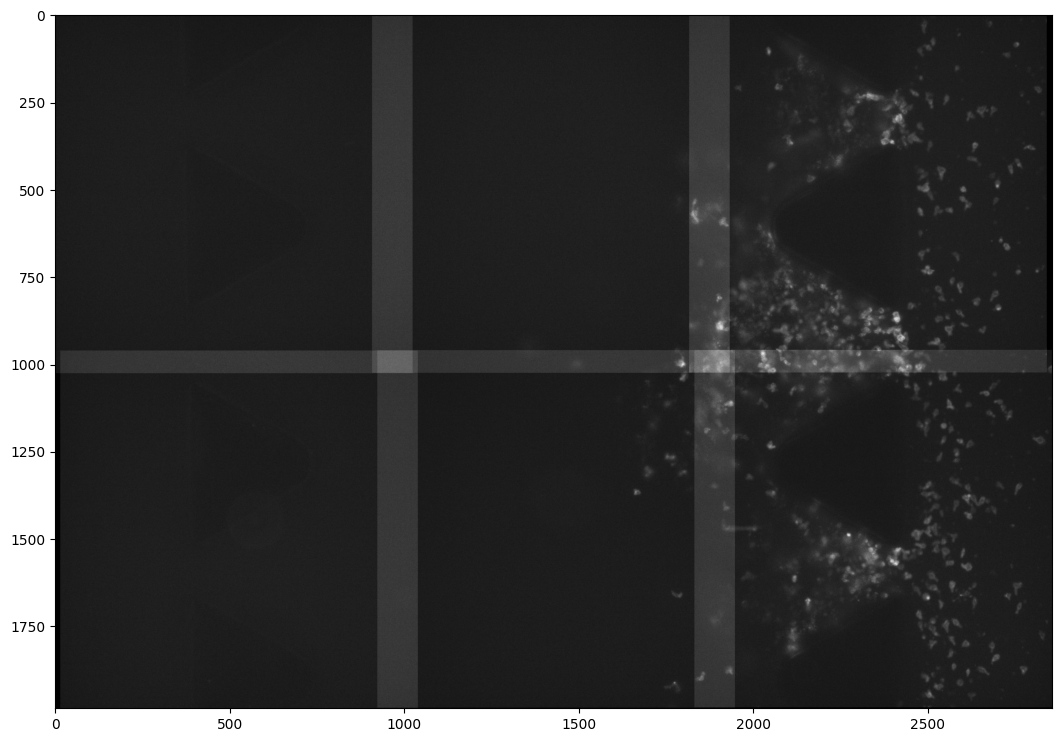

c:\Users\pcanaleta\Documents\GitHub\tanalysis\.venv\Lib\site-packages\tifffile\tifffile.py:3817: UserWarning: <tifffile.TiffWriter 'test.tiff'> truncating ImageJ file
  warnings.warn(


In [22]:
print(res_img_list[0].shape)
t=23
z=5
newname = r"C:\Users\pcanaleta\Documents\Cellpose_segmentation\EXP.HD6.Chips\EXP.HD6.1.1.MatekChips_CXCL10\24h\Originals\test.tiff"
im = res_img_list[0]

plt.figure(figsize=(16,9))
plt.imshow(res_img_list[0][t][z], cmap='gray')
plt.show()

tiff.imwrite(
    newname, 
    im[:,:,:,:].astype(np.uint16), 
    imagej=True,
    metadata={
        'axes':'TZYX'
    })

In [ ]:
abs_translations = {}
minr = 0
minc = 0
for row in np.arange(nrow):
    for col in np.arange(ncol):
        abs_translations[f'{row}{col}'] = [int(row*(drow+rr)+col*rr), int(row*rc+col*(dcol+rc))]
        minr_ = abs_translations[f'{row}{col}'][0]
        minc_ = abs_translations[f'{row}{col}'][1]
        if minr_<minr:
            minr=minr_
        if minc_<minc:
            minc=minc_
print(minr, minc)
print(abs_translations)

In [ ]:
H,W = imgs[0].shape[-2], imgs[0].shape[-1]
Hmax,Wmax = abs_translations[f'{nrow-1}{ncol-1}']
rerr = abs(minr)
cerr = abs(minc)
result = np.zeros((Hmax+H+2*rerr, Wmax+W+2*cerr))
print(result.shape)
z=7

for trans in abs_translations:
    srow = abs_translations[trans][0] + rerr
    scol = abs_translations[trans][1] + cerr
    erow = srow+H
    ecol = scol+W
    result[srow:erow,scol:ecol] = result[srow:erow,scol:ecol]+grid[trans][z]


plt.figure(figsize=(18,32))
plt.imshow(result, cmap='gray')
plt.show()

In [ ]:
timestamp = imgs[0][90]
positions = info['mosaic_position']
grid = {}
eq_grid = {}
nrow = 0
ncol = 0
z = 5

for pos, tile in zip(positions, timestamp):
    #Recorder of number of rows and cols
    if pos[1]+1>nrow:
        nrow=pos[1]+1
    if pos[0]+1>ncol:
        ncol=pos[0]+1
    #Assigning to the dictionary the corresponding image to each combination of row, col
    eq_tile = exposure.equalize_adapthist(tile, clip_limit=0.75)
    grid[f'{pos[1]}{pos[0]}']=tile
    eq_grid[f'{pos[1]}{pos[0]}'] = eq_tile

fig, ax = plt.subplots(2,3)
for row in range(0,2):
    for col in range(0,3):
        ax[row, col].imshow(grid[f'{row}{col}'][z], cmap='gray')

fig2, ax2 = plt.subplots(2,3)
for row in range(0,2):
    for col in range(0,3):
        ax2[row, col].imshow(eq_grid[f'{row}{col}'][z], cmap='gray')

In [ ]:
translations = [] #Saving vertical an horizontal translations for each image
nccv = -np.inf
ncch = -np.inf
Tvrow = 0
Tvcol = []
Throw = []
Thcol = 0
n=20
for row in range(0, nrow):
    for col in range(0, ncol):
        im = grid[f'{row}{col}'][z]
        H,W = im.shape
        if row!=0:
            im2 = grid[f'{row-1}{col}'][z]
            nccv_, Tvrow_, Tvcol_ = stitching.pciam(im2, im, n)
            print(f'Tv:{nccv_, Tvrow_, Tvcol_}')
            if abs(Tvcol_)<int(W/5):
                Tvcol.append(Tvcol_)
            if nccv<nccv_:
                nccv = nccv_
                Tvrow = Tvrow_
        if col!=0:
            im2 = grid[f'{row}{col-1}'][z]
            ncch_, Throw_, Thcol_ = stitching.pciam(im2, im, n)
            print(f'Th:{ncch_, Throw_, Thcol_}')
            if abs(Throw_)<int(H/5):
                Throw.append(Throw_)
            if ncch<ncch_:
                ncch = ncch_
                Thcol = Thcol_

if Throw == []:
    Throw = [0]
if Tvcol == []:
    Tvcol = [0]
Tv = [int(Tvrow), int(np.average(Tvcol))]
Th = [int(np.average(Throw)), int(Thcol)]

rr = Th[0]
rc = Tv[1]
drow = Th[1]-rr
dcol = Tv[0]-rc
print(rr, drow, rc, dcol)

In [ ]:
abs_translations = {}
minr = 0
minc = 0
for row in np.arange(nrow):
    for col in np.arange(ncol):
        abs_translations[f'{row}{col}'] = [int(row*(drow+rr)+col*rr), int(row*rc+col*(dcol+rc))]
        minr_ = abs_translations[f'{row}{col}'][0]
        minc_ = abs_translations[f'{row}{col}'][1]
        if minr_<minr:
            minr=minr_
        if minc_<minc:
            minc=minc_
print(minr, minc)
print(abs_translations)

In [ ]:
H,W = np.shape(grid['00'][0])
Hmax,Wmax = abs_translations[f'{nrow-1}{ncol-1}']
rerr = abs(minr)
cerr = abs(minc)
result = np.zeros((Hmax+H+2*rerr, Wmax+W+2*cerr))
print(result.shape)
z=7

for trans in abs_translations:
    srow = abs_translations[trans][0] + rerr
    scol = abs_translations[trans][1] + cerr
    erow = srow+H
    ecol = scol+W
    result[srow:erow,scol:ecol] = result[srow:erow,scol:ecol]+grid[trans][z]


plt.figure(figsize=(18,32))
plt.imshow(result, cmap='gray')
plt.show()